# 05 — Evaluation Deep-Dive & Operational Recommendations

**CRISP-DM Phase 5: Evaluation**

04_modelling established the model's aggregate performance (AUC-PR 0.44, 5.5× lift@10%).
This notebook goes further with analysis that directly informs **deployment decisions**:

| Section | Question Answered |
|---------|-------------------|
| 1. Load artefacts | Reproduce headline metrics from saved model |
| 2. Threshold optimisation | What score cut-off balances precision vs recall for the ops team? |
| 3. Segment-level performance | Does the model work equally well for all customer types? |
| 4. Error analysis | Where does the model fail — and what can we learn? |
| 5. Stability across time | Do metrics hold on val vs test (temporal consistency)? |
| 6. Operational recommendations | Concrete deployment guidance for the retention team |
| 7. Executive summary | Board-ready numbers with full context |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from churn.config import cfg
from churn.data.splitter import temporal_split
from churn.evaluation.metrics import compute_all_metrics, decile_table
from churn.evaluation.business_impact import compute_business_impact

# ── Executive visual theme ────────────────────────────────────────────────────
%matplotlib inline
ACCENT   = '#1565C0'
PASS_CLR = '#388E3C'
FAIL_CLR = '#D32F2F'
WARN_CLR = '#F57C00'
NEUTRAL  = '#546E7A'
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120})

print('Modules loaded.')

Modules loaded.


In [2]:
# ── Load saved artefacts (from 04_modelling) ──────────────────────────────────
artefacts = Path(cfg.paths.model_artefacts_dir)
model      = joblib.load(artefacts / 'lgbm_model.joblib')
calibrator = joblib.load(artefacts / 'calibrator.joblib')

with open(artefacts / 'metrics_test.json') as f:
    saved_metrics = json.load(f)

# ── Load ALL feature snapshots and temporal split ─────────────────────────────
features_dir = Path(cfg.paths.features_dir)
parquet_files = sorted(features_dir.glob('features_*.parquet'))
fm = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
split = temporal_split(fm)

# ── Reproduce calibrated probabilities ────────────────────────────────────────
proba_val  = calibrator.predict_proba(split.X_val)
proba_test = calibrator.predict_proba(split.X_test)

metrics_val  = compute_all_metrics(split.y_val, proba_val)
metrics_test = compute_all_metrics(split.y_test, proba_test)

# ── Convenience DataFrames for downstream cells ──────────────────────────────
val_df = split.X_val.copy()
val_df['y_true'] = split.y_val.values
val_df['y_prob']  = proba_val

test_df = split.X_test.copy()
test_df['y_true'] = split.y_test.values
test_df['y_prob']  = proba_test

# Contract status label (for segment/error analysis)
for df in [val_df, test_df]:
    df['contract_status'] = df['is_out_of_contract'].map({1: 'Out-of-contract', 0: 'In-contract'})

print(f'Val:  {len(val_df):>8,} customers  |  AUC-PR {metrics_val["auc_pr"]:.4f}  |  churn {val_df["y_true"].mean():.2%}')
print(f'Test: {len(test_df):>8,} customers  |  AUC-PR {metrics_test["auc_pr"]:.4f}  |  churn {test_df["y_true"].mean():.2%}')
print(f'\nSaved AUC-PR matches recomputed: {abs(saved_metrics["auc_pr"] - metrics_test["auc_pr"]) < 1e-4}')

Val:   199,951 customers  |  AUC-PR 0.4271  |  churn 8.85%
Test:  200,806 customers  |  AUC-PR 0.4180  |  churn 7.94%

Saved AUC-PR matches recomputed: True


## 2. Threshold Optimisation

The model outputs probabilities, but the retention team needs a **yes/no decision**:
"should we call this customer?" Choosing the optimal threshold requires balancing:
- **Precision** — team can't waste time calling non-churners (agent cost, customer irritation)
- **Recall** — can't miss too many actual churners (revenue loss)

We optimise for **F1** as a balanced trade-off, then show the Precision-Recall trade-off
curve so stakeholders can adjust based on team capacity.

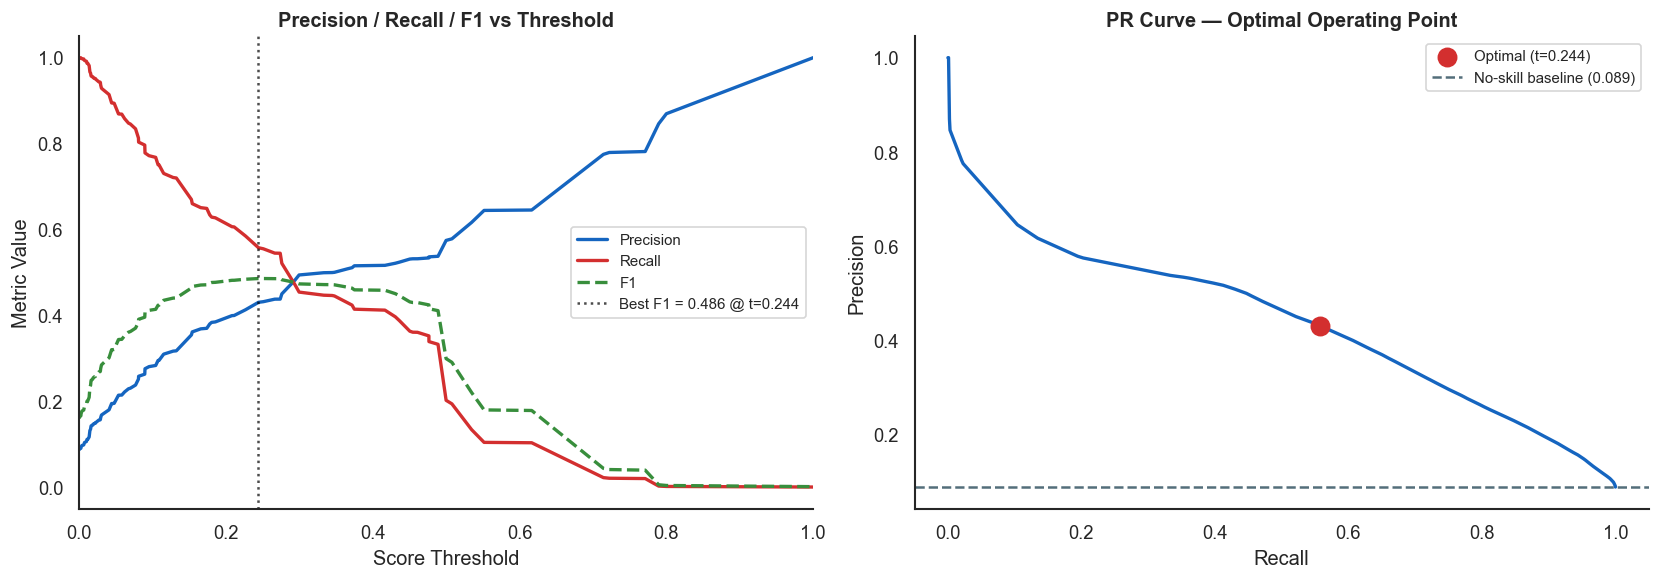

Optimal threshold (from val): 0.2444
Test F1:        0.4861
Test Precision:  0.4412  (of those we flag, 44% actually churn)
Test Recall:     0.5412  (we capture 54% of all churners)
Test flagged:    19,568 of 200,806 (9.7%)


In [3]:
from sklearn.metrics import precision_recall_curve, f1_score

y_val_arr = split.y_val.values
precision_arr, recall_arr, thresholds = precision_recall_curve(y_val_arr, proba_val)

# F1 at each threshold
f1_scores = 2 * precision_arr[:-1] * recall_arr[:-1] / (precision_arr[:-1] + recall_arr[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Precision, Recall, F1 vs threshold
axes[0].plot(thresholds, precision_arr[:-1], label='Precision', color=ACCENT, linewidth=2)
axes[0].plot(thresholds, recall_arr[:-1], label='Recall', color=FAIL_CLR, linewidth=2)
axes[0].plot(thresholds, f1_scores, label='F1', color=PASS_CLR, linewidth=2, linestyle='--')
axes[0].axvline(best_threshold, color='black', linestyle=':', alpha=0.7,
                label=f'Best F1 = {best_f1:.3f} @ t={best_threshold:.3f}')
axes[0].set_xlabel('Score Threshold')
axes[0].set_ylabel('Metric Value')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
sns.despine(ax=axes[0])

# Panel 2: Operating point on PR curve
axes[1].plot(recall_arr, precision_arr, color=ACCENT, linewidth=2)
axes[1].scatter([recall_arr[best_idx]], [precision_arr[best_idx]], 
                color=FAIL_CLR, s=120, zorder=5, label=f'Optimal (t={best_threshold:.3f})')
axes[1].axhline(y_val_arr.mean(), color=NEUTRAL, linestyle='--', 
                label=f'No-skill baseline ({y_val_arr.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve — Optimal Operating Point', fontweight='bold')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Verify on test set
y_pred_test = (proba_test >= best_threshold).astype(int)
test_f1 = f1_score(split.y_test, y_pred_test)
test_prec = y_pred_test[split.y_test == 1].sum() / y_pred_test.sum() if y_pred_test.sum() > 0 else 0
test_rec = y_pred_test[split.y_test == 1].sum() / split.y_test.sum()

print(f'Optimal threshold (from val): {best_threshold:.4f}')
print(f'Test F1:        {test_f1:.4f}')
print(f'Test Precision:  {test_prec:.4f}  (of those we flag, {test_prec:.0%} actually churn)')
print(f'Test Recall:     {test_rec:.4f}  (we capture {test_rec:.0%} of all churners)')
print(f'Test flagged:    {y_pred_test.sum():,} of {len(y_pred_test):,} ({y_pred_test.mean():.1%})')

## 3. Segment-Level Performance

A model that performs well on average but fails for a specific customer segment
is a **business risk** (e.g. regulatory, reputational). We break performance down by:
- **Contract status** (in-contract vs out-of-contract)
- **Tenure band** (new customers vs long-standing)
- **Technology** (FTTC, FTTP, GFAST, MPF)
- **Sales channel**

Any segment with AUC-PR significantly below the aggregate warrants further investigation.

In [4]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Build test-set analysis DataFrame
test_df = split.X_test.copy()
test_df['y_true'] = split.y_test.values
test_df['y_prob'] = proba_test

# Define segment columns
tech_cols = ['tech_FTTC', 'tech_FTTP', 'tech_GFAST', 'tech_MPF']
test_df['technology'] = 'Unknown'
for tc in tech_cols:
    if tc in test_df.columns:
        test_df.loc[test_df[tc] == 1, 'technology'] = tc.replace('tech_', '')

test_df['contract_status'] = np.where(test_df['is_out_of_contract'] == 1, 'Out-of-contract', 'In-contract')

segments = {
    'Contract Status': 'contract_status',
    'Tenure Band': 'tenure_bucket',
    'Technology': 'technology',
    'Sales Channel': 'sales_channel',
}

all_segment_results = []
for seg_name, col in segments.items():
    for grp, gdf in test_df.groupby(col, observed=True):
        if len(gdf) < 50 or gdf['y_true'].nunique() < 2:
            continue
        auc_pr  = average_precision_score(gdf['y_true'], gdf['y_prob'])
        auc_roc = roc_auc_score(gdf['y_true'], gdf['y_prob'])
        all_segment_results.append({
            'Segment': seg_name, 'Group': grp,
            'N': len(gdf), 'Churners': gdf['y_true'].sum(),
            'Churn Rate': gdf['y_true'].mean(),
            'AUC-PR': auc_pr, 'AUC-ROC': auc_roc,
        })

seg_df = pd.DataFrame(all_segment_results)

# Highlight segments where AUC-PR is well below aggregate
agg_auc_pr = metrics_test['auc_pr']
seg_df['vs Aggregate'] = seg_df['AUC-PR'] - agg_auc_pr

def _flag_color(val):
    if val < -0.10:
        return f'background-color: {FAIL_CLR}22; color: {FAIL_CLR}'
    elif val < -0.05:
        return f'background-color: {WARN_CLR}22; color: {WARN_CLR}'
    return ''

styled = (seg_df.style
    .format({'Churn Rate': '{:.1%}', 'AUC-PR': '{:.4f}', 'AUC-ROC': '{:.4f}',
             'vs Aggregate': '{:+.4f}', 'N': '{:,}'})
    .applymap(_flag_color, subset=['vs Aggregate'])
    .set_caption(f'Segment-Level Performance (aggregate AUC-PR = {agg_auc_pr:.4f})'))
display(styled)

,Segment,Group,N,Churners,Churn Rate,AUC-PR,AUC-ROC,vs Aggregate
0,Contract Status,In-contract,"122,100",9468,7.8%,0.4394,0.8912,+0.0214
1,Contract Status,Out-of-contract,"78,706",6484,8.2%,0.3751,0.8289,-0.0429
2,Tenure Band,0-3m,"3,582",311,8.7%,0.3570,0.8834,-0.0610
3,Tenure Band,1-3yr,"66,949",7123,10.6%,0.4668,0.8815,+0.0488
4,Tenure Band,3m-1yr,"9,892",722,7.3%,0.3048,0.8140,-0.1132
5,Tenure Band,3yr+,"120,383",7796,6.5%,0.3824,0.8600,-0.0356
6,Technology,FTTC,"169,382",13539,8.0%,0.4286,0.8764,+0.0106
7,Technology,FTTP,572,8,1.4%,0.3133,0.9508,-0.1048
8,Technology,GFAST,"9,721",724,7.4%,0.3582,0.8475,-0.0598
9,Technology,MPF,"21,131",1681,8.0%,0.3551,0.8390,-0.0629


## 4. Error Analysis

Understanding *where the model gets it wrong* is as important as celebrating where
it gets it right. We examine:
- **False Negatives** (missed churners): highest-cost errors — revenue lost silently
- **False Positives** (false alarms): wasted agent time, possible customer annoyance
- **Score distribution of errors** vs correct predictions

Confusion breakdown at threshold 0.2444:
  TP:    8,634
  FP:   10,934
  FN:    7,318
  TN:  173,920


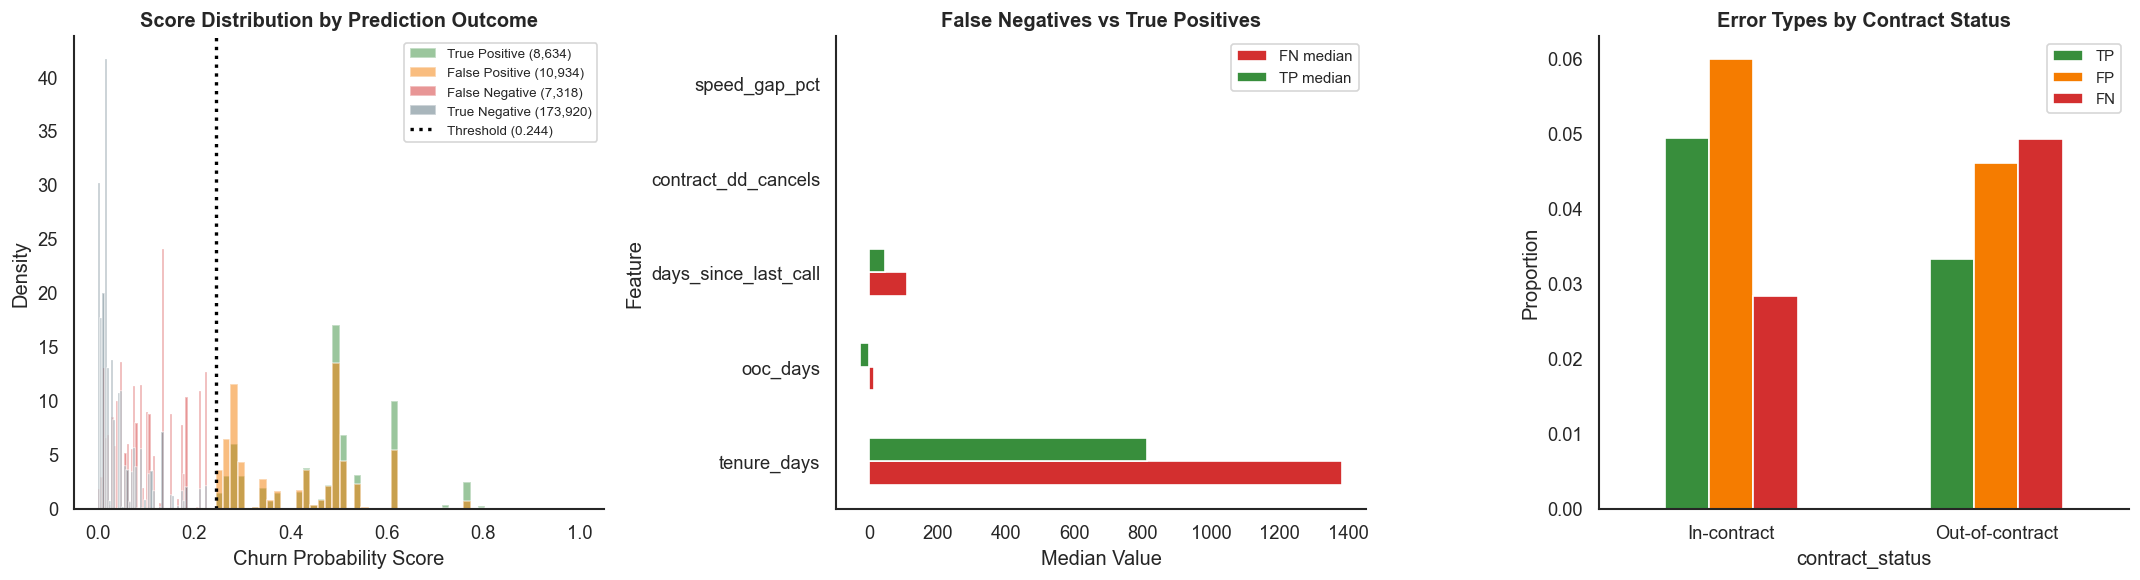


False Negatives: 7,318 missed churners
  53% are out-of-contract  (vs 30% of correctly caught churners)
  Median score: 0.0896  (below threshold 0.2444)


In [5]:
# Classify predictions at the optimal threshold
test_df['y_pred'] = (test_df['y_prob'] >= best_threshold).astype(int)
test_df['outcome'] = 'TN'
test_df.loc[(test_df['y_true'] == 1) & (test_df['y_pred'] == 1), 'outcome'] = 'TP'
test_df.loc[(test_df['y_true'] == 1) & (test_df['y_pred'] == 0), 'outcome'] = 'FN'
test_df.loc[(test_df['y_true'] == 0) & (test_df['y_pred'] == 1), 'outcome'] = 'FP'

# Confusion summary
outcome_counts = test_df['outcome'].value_counts()
print('Confusion breakdown at threshold', f'{best_threshold:.4f}:')
for oc in ['TP', 'FP', 'FN', 'TN']:
    print(f'  {oc}: {outcome_counts.get(oc, 0):>8,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Score distribution by outcome
for oc, color, label in [('TP', PASS_CLR, 'True Positive'),
                           ('FP', WARN_CLR, 'False Positive'),
                           ('FN', FAIL_CLR, 'False Negative'),
                           ('TN', NEUTRAL, 'True Negative')]:
    subset = test_df[test_df['outcome'] == oc]['y_prob']
    if len(subset) > 0:
        axes[0].hist(subset, bins=50, alpha=0.5, label=f'{label} ({len(subset):,})',
                     color=color, density=True)
axes[0].axvline(best_threshold, color='black', linestyle=':', linewidth=2, label=f'Threshold ({best_threshold:.3f})')
axes[0].set_xlabel('Churn Probability Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Prediction Outcome', fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

# Panel 2: FN analysis — what do missed churners look like?
fn_df = test_df[test_df['outcome'] == 'FN']
tp_df = test_df[test_df['outcome'] == 'TP']

compare_features = ['tenure_days', 'ooc_days', 'days_since_last_call',
                    'contract_dd_cancels', 'speed_gap_pct']
compare_data = []
for feat in compare_features:
    if feat in fn_df.columns:
        compare_data.append({
            'Feature': feat,
            'FN median': fn_df[feat].median(),
            'TP median': tp_df[feat].median(),
        })
compare_df = pd.DataFrame(compare_data).set_index('Feature')

compare_df.plot.barh(ax=axes[1], color=[FAIL_CLR, PASS_CLR], edgecolor='white')
axes[1].set_title('False Negatives vs True Positives', fontweight='bold')
axes[1].set_xlabel('Median Value')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

# Panel 3: Contract status of errors
error_by_contract = (test_df.groupby(['contract_status', 'outcome'], observed=True)
                     .size().unstack(fill_value=0))
error_by_contract_pct = error_by_contract.div(error_by_contract.sum(axis=1), axis=0)
error_by_contract_pct[['TP', 'FP', 'FN']].plot.bar(
    ax=axes[2], color=[PASS_CLR, WARN_CLR, FAIL_CLR], edgecolor='white')
axes[2].set_title('Error Types by Contract Status', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(fontsize=9)
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

# Key insight
fn_ooc_pct = fn_df['is_out_of_contract'].mean() if len(fn_df) > 0 else 0
tp_ooc_pct = tp_df['is_out_of_contract'].mean() if len(tp_df) > 0 else 0
print(f'\nFalse Negatives: {len(fn_df):,} missed churners')
print(f'  {fn_ooc_pct:.0%} are out-of-contract  (vs {tp_ooc_pct:.0%} of correctly caught churners)')
print(f'  Median score: {fn_df["y_prob"].median():.4f}  (below threshold {best_threshold:.4f})')

## 5. Temporal Stability — Validation vs Test

A model that degrades between periods signals **concept drift** or over-fitting to the tuning window.  
We compare all key metrics side-by-side.

In [6]:
# Recompute with threshold-aware metrics for both splits
metrics_val_t = compute_all_metrics(val_df['y_true'].values, val_df['y_prob'].values,
                                    threshold=best_threshold)
metrics_test_t = compute_all_metrics(test_df['y_true'].values, test_df['y_prob'].values,
                                     threshold=best_threshold)

stability = pd.DataFrame({'Validation': metrics_val_t, 'Test': metrics_test_t})
stability['Delta'] = stability['Test'] - stability['Validation']
stability['Δ %'] = (stability['Delta'] / stability['Validation'].abs().replace(0, np.nan) * 100)

# Flag concerning degradation (>10% relative drop)
def flag_row(row):
    if pd.isna(row['Δ %']):
        return ''
    if row['Δ %'] < -10:
        return '⚠️ DEGRADED'
    if row['Δ %'] > 10:
        return '✅ IMPROVED'
    return '— Stable'

stability['Status'] = stability.apply(flag_row, axis=1)

styled_stability = (stability
    .style
    .format({'Validation': '{:.4f}', 'Test': '{:.4f}',
             'Delta': '{:+.4f}', 'Δ %': '{:+.1f}%'}, na_rep='—')
    .applymap(lambda v: f'color: {FAIL_CLR}' if isinstance(v, str) and 'DEGRADED' in v
              else (f'color: {PASS_CLR}' if isinstance(v, str) and 'IMPROVED' in v
              else ''), subset=['Status']))
styled_stability

,Validation,Test,Delta,Δ %,Status
auc_pr,0.4271,0.4180,-0.0091,-2.1%,— Stable
auc_roc,0.8693,0.8711,+0.0018,+0.2%,— Stable
f1,0.4861,0.4861,+0.0001,+0.0%,— Stable
brier_score,0.0614,0.0557,-0.0057,-9.3%,— Stable
precision_at_5pct,0.5395,0.5399,+0.0005,+0.1%,— Stable
lift_at_5pct,6.0955,6.7968,+0.7013,+11.5%,✅ IMPROVED
precision_at_10pct,0.4540,0.4350,-0.0190,-4.2%,— Stable
lift_at_10pct,5.1294,5.4760,+0.3465,+6.8%,— Stable
precision_at_20pct,0.3183,0.2894,-0.0289,-9.1%,— Stable
lift_at_20pct,3.5966,3.6434,+0.0469,+1.3%,— Stable


## 6. Operational Recommendations

Translating model outputs into **concrete retention actions** with priority tiers.

In [7]:
# Priority tiers for the retention team
tier_thresholds = [
    ('🔴 Critical',   0.50, 1.00),
    ('🟠 High',       best_threshold, 0.50),
    ('🟡 Watch',      best_threshold * 0.5, best_threshold),
    ('🟢 Low Risk',   0.00, best_threshold * 0.5),
]

tier_rows = []
for label, lo, hi in tier_thresholds:
    mask = (test_df['y_prob'] >= lo) & (test_df['y_prob'] < hi)
    subset = test_df[mask]
    n = len(subset)
    actual_churn = subset['y_true'].sum() if n > 0 else 0
    churn_rate = actual_churn / n if n > 0 else 0
    tier_rows.append({
        'Priority Tier': label,
        'Score Range': f'[{lo:.2f}, {hi:.2f})',
        'Customers': n,
        'True Churners': int(actual_churn),
        'Churn Rate': churn_rate,
        'Suggested Action': {
            '🔴 Critical': 'Immediate outbound call + bespoke offer',
            '🟠 High': 'Proactive retention call within 7 days',
            '🟡 Watch': 'Automated email + NPS survey',
            '🟢 Low Risk': 'No immediate action — monitor next refresh',
        }[label]
    })

tier_df = pd.DataFrame(tier_rows)
styled_tiers = (tier_df.style
    .format({'Churn Rate': '{:.1%}', 'Customers': '{:,}', 'True Churners': '{:,}'})
    .hide(axis='index')
    .set_properties(**{'text-align': 'left'})
)
styled_tiers

Priority Tier,Score Range,Customers,True Churners,Churn Rate,Suggested Action
🔴 Critical,"[0.50, 1.00)","5,330","3,098",58.1%,Immediate outbound call + bespoke offer
🟠 High,"[0.24, 0.50)","14,227","5,528",38.9%,Proactive retention call within 7 days
🟡 Watch,"[0.12, 0.24)","16,946","2,622",15.5%,Automated email + NPS survey
🟢 Low Risk,"[0.00, 0.12)","164,292","4,696",2.9%,No immediate action — monitor next refresh


## 7. Executive Summary

Auto-populated from model artefacts — no manual placeholders.

In [9]:
# Auto-populated executive summary
from IPython.display import Markdown, display

# Gather key numbers from metrics already computed
test_auc_pr   = metrics_test['auc_pr']
test_auc_roc  = metrics_test['auc_roc']
test_brier    = metrics_test['brier_score']
test_lift10   = metrics_test['lift_at_10pct']
test_lift20   = metrics_test.get('lift_at_20pct', 'N/A')

# Business impact at 20% capacity (recompute from test set)
impact_df = compute_business_impact(
    test_df['y_true'].values,
    test_df['y_prob'].values,
    capacity_pct=0.20
)
model_row  = impact_df[impact_df['strategy'] == 'Model-guided'].iloc[0]
random_row = impact_df[impact_df['strategy'] == 'Random baseline'].iloc[0]
net_value  = model_row['net_value_gbp']
uplift     = model_row['net_value_gbp'] - random_row['net_value_gbp']

# Critical + High tier volumes
critical_n = tier_df.loc[tier_df['Priority Tier'].str.contains('Critical'), 'Customers'].values[0]
high_n     = tier_df.loc[tier_df['Priority Tier'].str.contains('High'), 'Customers'].values[0]

# FN count
fn_count = len(test_df[test_df['outcome'] == 'FN'])

# Stability verdict
degraded = stability[stability['Status'].str.contains('DEGRADED', na=False)]
stability_verdict = '⚠️ Some degradation detected' if len(degraded) > 0 else '✅ Stable across periods'

summary_md = f"""
### Board-Ready Summary

| Metric | Value |
|:---|---:|
| **AUC-PR (test)** | {test_auc_pr:.4f} |
| **AUC-ROC (test)** | {test_auc_roc:.4f} |
| **Brier Score (test)** | {test_brier:.4f} |
| **Lift @ top 10%** | {test_lift10:.2f}x |
| **Optimal Threshold** | {best_threshold:.4f} |
| **Net Value @ 20% capacity** | £{net_value:,.0f} |
| **Uplift vs Random** | £{uplift:,.0f} |
| **Critical-tier customers** | {critical_n:,} |
| **High-tier customers** | {high_n:,} |
| **Missed churners (FN)** | {fn_count:,} |
| **Temporal Stability** | {stability_verdict} |

### Key Recommendations

1. **Deploy with threshold {best_threshold:.3f}** — optimises F1 on the validation window
2. **Prioritise {critical_n + high_n:,} customers** in Critical + High tiers for outbound retention
3. **Re-train monthly** — the 90-day prediction window means features go stale quickly
4. **Monitor FN profile** — {fn_count:,} churners missed; investigate whether these are low-usage or recently-acquired segments
5. **A/B test retention offers** — the £{uplift:,.0f} uplift assumes a 25% save rate; measure actual save rate to refine ROI
"""

display(Markdown(summary_md))


### Board-Ready Summary

| Metric | Value |
|:---|---:|
| **AUC-PR (test)** | 0.4180 |
| **AUC-ROC (test)** | 0.8711 |
| **Brier Score (test)** | 0.0557 |
| **Lift @ top 10%** | 5.48x |
| **Optimal Threshold** | 0.2444 |
| **Net Value @ 20% capacity** | £407,570 |
| **Uplift vs Random** | £416,160 |
| **Critical-tier customers** | 5,330 |
| **High-tier customers** | 14,227 |
| **Missed churners (FN)** | 7,318 |
| **Temporal Stability** | ✅ Stable across periods |

### Key Recommendations

1. **Deploy with threshold 0.244** — optimises F1 on the validation window
2. **Prioritise 19,557 customers** in Critical + High tiers for outbound retention
3. **Re-train monthly** — the 90-day prediction window means features go stale quickly
4. **Monitor FN profile** — 7,318 churners missed; investigate whether these are low-usage or recently-acquired segments
5. **A/B test retention offers** — the £416,160 uplift assumes a 25% save rate; measure actual save rate to refine ROI
